# Reto 01 — Regresión polinomial de grado *n* vs. Red Neuronal Artificial

## Estimación del precio de bienes raíces en Francia

> **Fuente del problema:** [Challenge Data #68 — *Real Estate Price Prediction*](https://challengedata.ens.fr/challenges/68),
> propuesto por el **Institut Louis Bachelier (ILB)** a través de su *ILB Datalab*.

### El problema

El ILB Datalab recopiló una base extensa de anuncios inmobiliarios franceses con el objetivo de responder una
pregunta concreta: **¿aportan las fotografías del inmueble información complementaria que permita estimar el
precio con mayor precisión que usando solo los datos tabulares del anuncio?**

En palabras del organizador, *"the project is a regression task that deals with real estate price estimation"*.
El conjunto original consta de:

- ≈ **50,000 anuncios** de inmuebles en Francia, divididos por el organizador en ≈ 40,000 de entrenamiento y
  ≈ 10,000 de prueba (partición 80/20).
- Para cada anuncio, **entre 1 y 6 fotografías** (≈ 300,000 imágenes, ≈ 30 GB en total).
- La variable respuesta es `price`: el precio en euros al que se lista la propiedad.

El *benchmark* publicado por el ILB usa **XGBoost** sobre la unión de (a) las variables tabulares preprocesadas y
(b) *embeddings* de imagen construidos concatenando el color promedio RGB, los conteos/cuantiles/media de la
versión en escala de grises y los mismos estadísticos tras aplicar un filtro de bordes de Sobel. El organizador
además señala explícitamente que *"value results interpretability"*.

### Alcance de este notebook

En este repositorio disponemos **únicamente de la parte tabular** del reto (`X.csv` y `y.csv`, 37,368 anuncios);
la carpeta de imágenes no está incluida, por lo que la componente multimodal del reto original queda fuera de
alcance. Tampoco es pública la métrica oficial de la plataforma (requiere autenticación), así que aquí se
reportan **MAE, RMSE, R², MAPE y MedAPE** calculados sobre euros.

### Objetivo

Comparar dos familias de modelos sobre **exactamente el mismo pipeline de ingeniería de características**:

| | Modelo A | Modelo B |
|---|---|---|
| **Familia** | Regresión polinomial de grado *n* | Red neuronal artificial (ANN) |
| **Implementación** | `PolynomialFeatures` + `RidgeCV` (scikit-learn) | Capas densas en Keras |
| **No linealidad** | Explícita: productos de las variables hasta grado *n* | Implícita: activaciones **ReLU** |
| **Salida** | Lineal sobre las variables expandidas | Neurona única con activación **sigmoide** |
| **Selección de hiperparámetros** | Validación cruzada sobre *n* ∈ {1, 2, 3} | *Early stopping* sobre un conjunto de validación |

Al compartir el preprocesamiento, cualquier diferencia de desempeño es atribuible al modelo y no a las
características que recibe.

### Nota metodológica sobre la salida sigmoide

La activación sigmoide está acotada en el intervalo **[0, 1]**, mientras que los precios van de ≈ 24 mil € a
≈ 2.3 millones €. Por eso el objetivo se transforma con `y' = MinMax(log1p(price))`, y **ambos modelos se
entrenan sobre esa misma escala**. El logaritmo previo comprime la cola derecha (la distribución de precios es
fuertemente asimétrica) y el `MinMaxScaler` lleva el resultado al rango que la sigmoide puede representar. Todas
las métricas se calculan tras deshacer la transformación, es decir, **en euros**.

---

## 1. Configuración del entorno

Importamos las bibliotecas. El bloque de scikit-learn concentra todo lo necesario para el pipeline compartido
(imputación, codificación, escalamiento, expansión polinomial y validación cruzada) y el bloque de Keras
construye la red densa. `TargetEncoder` requiere scikit-learn ≥ 1.3 y realiza validación cruzada interna, lo
que evita la fuga de información al codificar variables de cardinalidad alta como `city` y `postal_code`.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    StandardScaler,
    TargetEncoder,
)

import keras
from keras import layers

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

Fijamos la semilla en NumPy y en Keras para que la partición de datos, la validación cruzada y la
inicialización de los pesos de la red sean reproducibles entre ejecuciones.

In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

RUTA_DATOS = Path("../data/real-state")

print("Keras:", keras.__version__, "| backend:", keras.backend.backend())

Keras: 3.14.1 | backend: tensorflow


---

## 2. Carga y entendimiento de los datos

Leemos las características (`X.csv`) y la variable respuesta (`y.csv`). Forzamos `postal_code` a cadena porque
los códigos postales franceses llevan ceros a la izquierda (`06270`), que se perderían al leerlos como entero;
además se trata de un identificador nominal, no de una cantidad.

In [3]:
X_raw = pd.read_csv(RUTA_DATOS / "X.csv", dtype={"postal_code": str})
y_raw = pd.read_csv(RUTA_DATOS / "y.csv")

print("X:", X_raw.shape, "| y:", y_raw.shape)
X_raw.head(3)

X: (37368, 27) | y: (37368, 2)


,id_annonce,property_type,approximate_latitude,approximate_longitude,city,postal_code,size,floor,land_size,energy_performance_value,energy_performance_category,ghg_value,ghg_category,exposition,nb_rooms,nb_bedrooms,nb_bathrooms,nb_parking_places,nb_boxes,nb_photos,has_a_balcony,nb_terraces,has_a_cellar,has_a_garage,has_air_conditioning,last_floor,upper_floors
0,35996577,appartement,43.643880,7.117183,villeneuve-loubet,06270,63.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,NaN,0.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,35811033,appartement,45.695757,4.895610,venissieux,69200,90.0,3.0,NaN,223.0,D,52.0,E,NaN,5.0,4.0,NaN,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,35731841,maison,47.966791,-1.220451,moutiers,35130,61.0,NaN,370.0,NaN,NaN,NaN,NaN,Sud,2.0,1.0,NaN,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Unimos por `id_annonce` de forma explícita para no depender de que ambos archivos estén en el mismo orden, y
usamos ese identificador como índice: es una llave del anuncio, no una característica predictiva, así que no
debe entrar al modelo.

In [4]:
datos = X_raw.merge(y_raw, on="id_annonce", how="inner").set_index("id_annonce")

X_df = datos.drop(columns=["price"])
y_df = datos["price"]

print("Anuncios:", len(datos), "| características:", X_df.shape[1])
datos.head(3)

Anuncios: 37368 | características: 26


,property_type,approximate_latitude,approximate_longitude,city,postal_code,size,floor,land_size,energy_performance_value,energy_performance_category,ghg_value,ghg_category,exposition,nb_rooms,nb_bedrooms,nb_bathrooms,nb_parking_places,nb_boxes,nb_photos,has_a_balcony,nb_terraces,has_a_cellar,has_a_garage,has_air_conditioning,last_floor,upper_floors,price
id_annonce,,,,,,,,,,,,,,,,,,,,,,,,,,,
35996577,appartement,43.643880,7.117183,villeneuve-loubet,06270,63.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,NaN,0.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,355000.0
35811033,appartement,45.695757,4.895610,venissieux,69200,90.0,3.0,NaN,223.0,D,52.0,E,NaN,5.0,4.0,NaN,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,190000.0
35731841,maison,47.966791,-1.220451,moutiers,35130,61.0,NaN,370.0,NaN,NaN,NaN,NaN,Sud,2.0,1.0,NaN,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39000.0


El diccionario de datos que acompaña al reto describe cada columna y si es un campo obligatorio en la
plataforma web. Las columnas *no obligatorias* son justamente las que concentran los valores faltantes.

In [5]:
diccionario = pd.read_csv(RUTA_DATOS / "DataDictionary.csv").dropna(how="all")
diccionario

,Name (Type),Description,Compulsory field on web platform
0,id_annonce (str),unique listing identification code,True
1,price (float),price at which the property is listed,True
2,property_type (str),"property type (house, appatement…)",True
3,approximate_latitude (float),latitude of the proporty with a small random g...,False
4,approximate_longitude (float),longitude of the proporty with a small random ...,False
5,city (str),city in which the property is located,True
6,postal_code (int),postal code of the property,True
7,size (float),living area of the property,False
8,floor (float),floor at which the property is located,False
9,land_size (float),size of the land that comes with the property,False


Función auxiliar para describir el DataFrame: tipo, número y porcentaje de nulos, y cardinalidad. Es la
radiografía que determina qué estrategia de imputación y codificación merece cada columna.

In [6]:
def describe_datos(df):
    # Resumen por columna: tipo, nulos, % de nulos y número de valores únicos.
    resumen = pd.DataFrame(
        {
            "tipo": df.dtypes.astype(str),
            "nulos": df.isna().sum(),
            "pct_nulos": (df.isna().mean() * 100).round(1),
            "unicos": df.nunique(),
        }
    )
    return resumen.sort_values("pct_nulos", ascending=False)


describe_datos(X_df)

,tipo,nulos,pct_nulos,unicos
exposition,str,28274,75.7,12
floor,float64,27625,73.9,24
land_size,float64,21787,58.3,3721
ghg_value,float64,18838,50.4,188
ghg_category,str,18838,50.4,7
energy_performance_category,str,18300,49.0,7
energy_performance_value,float64,18300,49.0,642
nb_bathrooms,float64,13273,35.5,4
nb_bedrooms,float64,2733,7.3,44
nb_rooms,float64,1566,4.2,44


Observaciones que guían todo el preprocesamiento:

- **Faltantes masivos**: `exposition` (≈ 76 %), `floor` (≈ 74 %), `land_size` (≈ 58 %), `ghg_*` y
  `energy_performance_*` (≈ 50 %), `nb_bathrooms` (≈ 36 %). Eliminar esas filas destruiría el conjunto, y
  eliminar las columnas descartaría señal útil: **el hecho de que un campo falte es en sí informativo**
  (por ejemplo, `land_size` ausente sugiere departamento y no casa). Por eso imputamos y además creamos
  indicadores explícitos de ausencia.
- **Cardinalidad alta**: `city` (8,643) y `postal_code` (4,726) no pueden codificarse con *one-hot* sin generar
  miles de columnas casi vacías.
- **Escalas muy dispares**: `size` llega a 411,311 m² y `land_size` a 6,203,700 m², valores incompatibles con
  una vivienda y que corresponden a lotes/terrenos o a errores de captura.

La variable respuesta está fuertemente sesgada a la derecha. El histograma en escala original se concentra en
el extremo izquierdo, mientras que `log1p(price)` es casi simétrica: esa es la escala en la que conviene
entrenar y la que hace viable la salida sigmoide.

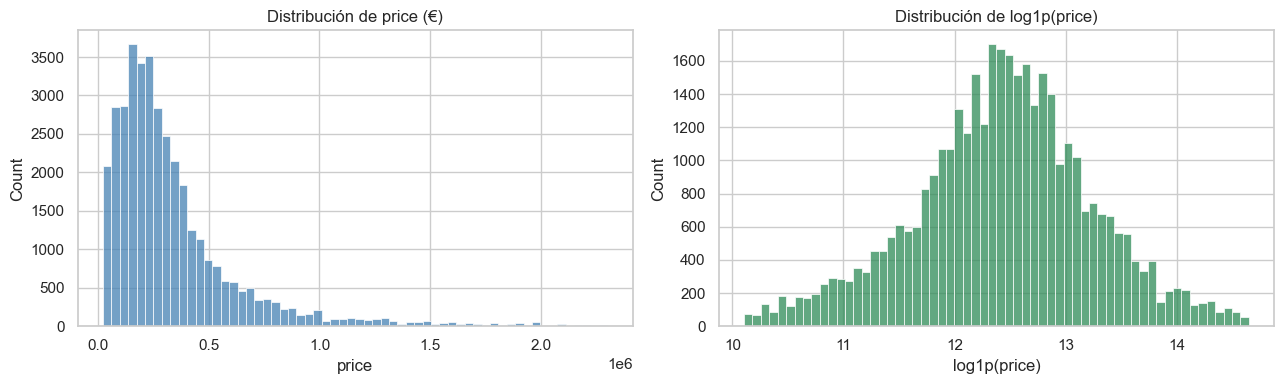

count      37368.0
mean      343221.0
std       308913.0
min        24465.0
1%         33500.0
25%       155462.0
50%       255250.0
75%       415000.0
95%       940000.0
99%      1680000.0
max      2299000.0
Name: price, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(y_df, bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de price (€)")
axes[0].set_xlabel("price")

sns.histplot(np.log1p(y_df), bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("Distribución de log1p(price)")
axes[1].set_xlabel("log1p(price)")

plt.tight_layout()
plt.show()

y_df.describe([0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).round(0)

Frecuencia de las variables categóricas. `property_type` está dominado por `appartement` y `maison`; la cola de
categorías raras (`château`, `moulin`, `péniche`…) se agrupará automáticamente con `min_frequency` en el
*one-hot*. Las categorías de desempeño energético (`A`–`G`) tienen un **orden natural** que aprovecharemos.

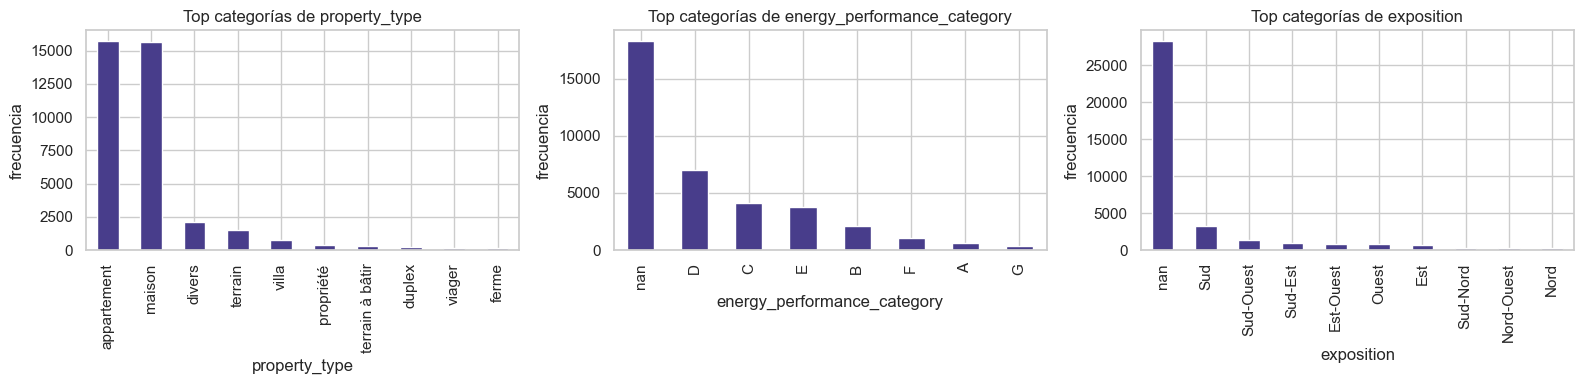

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["property_type", "energy_performance_category", "exposition"]):
    conteos = X_df[col].value_counts(dropna=False).head(10)
    conteos.plot(kind="bar", ax=ax, color="darkslateblue")
    ax.set_title(f"Top categorías de {col}")
    ax.set_ylabel("frecuencia")

plt.tight_layout()
plt.show()

Matriz de correlación de las variables numéricas contra `log1p(price)`. Se aprecia la colinealidad esperada
entre `nb_rooms` y `nb_bedrooms`, y la relación positiva de `size` con el precio: la regresión polinomial
explotará precisamente los productos entre estas variables.

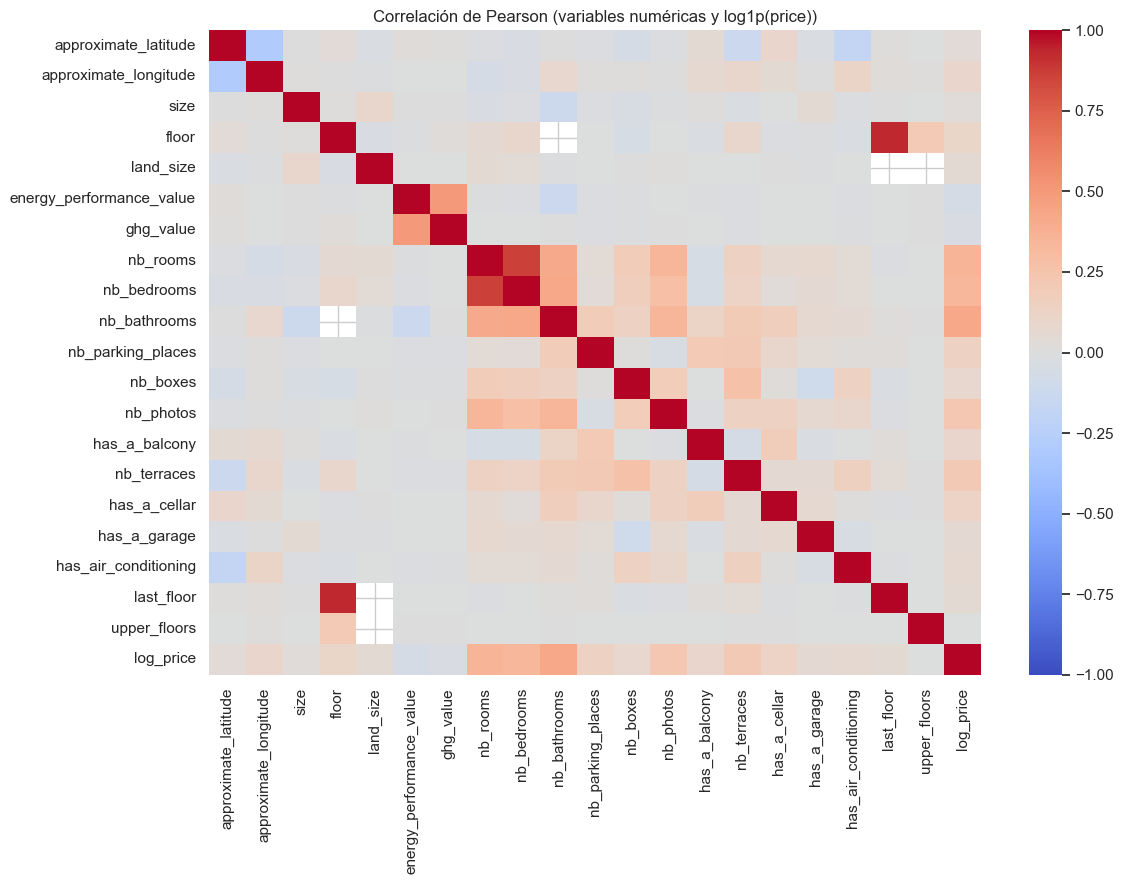

In [9]:
numericas = X_df.select_dtypes(include=np.number).columns.tolist()
corr = X_df[numericas].assign(log_price=np.log1p(y_df)).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap="coolwarm", square=False)
plt.title("Correlación de Pearson (variables numéricas y log1p(price))")
plt.tight_layout()
plt.show()

---

## 3. Transformación de la variable respuesta

La red termina en una neurona con activación **sigmoide**, cuyo rango es (0, 1). Para que el modelo pueda
representar el objetivo aplicamos dos transformaciones encadenadas:

1. `log1p(price)` — comprime la cola derecha y convierte el error relativo en error aproximadamente absoluto,
   que es lo natural en precios.
2. `MinMaxScaler` — lleva el resultado al intervalo [0, 1].

El escalador se **ajusta solo con el conjunto de entrenamiento** y la función `a_euros` deshace ambas
transformaciones para poder reportar todas las métricas en euros. Es indispensable que el modelo polinomial
use exactamente el mismo objetivo, de lo contrario la comparación no sería válida.

Definimos las funciones de transformación y su inversa. `a_euros` recorta a [0, 1] antes de invertir porque el
modelo polinomial —a diferencia de la sigmoide— sí puede predecir fuera de ese rango, y `expm1` de un valor
desmedido produciría precios absurdos.

In [10]:
escalador_y = MinMaxScaler()


def a_escala_modelo(precios, ajustar=False):
    # price (€) -> log1p -> MinMax -> [0, 1]
    log_precios = np.log1p(np.asarray(precios, dtype=float)).reshape(-1, 1)
    if ajustar:
        return escalador_y.fit_transform(log_precios).ravel()
    return escalador_y.transform(log_precios).ravel()


def a_euros(y_escalado):
    # [0, 1] -> MinMax^-1 -> expm1 -> price (€)
    y_clip = np.clip(np.asarray(y_escalado, dtype=float), 0.0, 1.0).reshape(-1, 1)
    return np.expm1(escalador_y.inverse_transform(y_clip)).ravel()

Función única de evaluación, usada por ambos modelos sobre **euros** para que las cifras sean directamente
comparables e interpretables:

- **MAE** — error absoluto medio, en euros.
- **RMSE** — penaliza más los errores grandes (los inmuebles caros).
- **R²** — proporción de varianza explicada.
- **MAPE / MedAPE** — error porcentual medio y mediano; el mediano es robusto a los atípicos.

In [11]:
def evaluar(nombre, y_true_eur, y_pred_eur):
    # Todas las métricas se calculan en euros, tras invertir la transformación del objetivo.
    ape = np.abs(y_pred_eur - y_true_eur) / y_true_eur
    return {
        "modelo": nombre,
        "MAE (€)": mean_absolute_error(y_true_eur, y_pred_eur),
        "RMSE (€)": np.sqrt(mean_squared_error(y_true_eur, y_pred_eur)),
        "R2": r2_score(y_true_eur, y_pred_eur),
        "MAPE (%)": mean_absolute_percentage_error(y_true_eur, y_pred_eur) * 100,
        "MedAPE (%)": np.median(ape) * 100,
    }

---

## 4. Partición entrenamiento / prueba

Separamos 80 / 20 con la misma semilla. El conjunto de validación que usa la red para el *early stopping* se
extrae **del entrenamiento** (`validation_split=0.15` en `fit`), nunca del conjunto de prueba: este último se
toca una sola vez, al final, para reportar el desempeño de ambos modelos.

In [12]:
X_train, X_test, y_train_eur, y_test_eur = train_test_split(
    X_df,
    y_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

# El escalador del objetivo se ajusta SOLO con entrenamiento.
y_train = a_escala_modelo(y_train_eur, ajustar=True)
y_test = a_escala_modelo(y_test_eur)

print("train:", X_train.shape, "| test:", X_test.shape)
print(f"y_train en escala del modelo: min={y_train.min():.3f}  max={y_train.max():.3f}")

train: (29894, 26) | test: (7474, 26)
y_train en escala del modelo: min=0.000  max=1.000


---

## 5. Ingeniería de características (pipeline compartido)

Esta es la pieza central del reto: **un solo pipeline alimenta a los dos modelos**. Se construye en tres etapas
encadenadas, todas ajustadas exclusivamente sobre el conjunto de entrenamiento:

1. **Winsorización** de las variables con atípicos extremos (recorte a los percentiles 1 y 99 aprendidos en
   entrenamiento).
2. **Características derivadas** — logaritmos, razones, conteos agregados, distancias geográficas e
   indicadores de ausencia. Es una transformación fila a fila, sin estado, por lo que no puede filtrar
   información entre particiones.
3. **`ColumnTransformer`** — imputación, codificación y escalamiento, con una estrategia por tipo de variable.

Distancia de Haversine: convierte un par (latitud, longitud) en kilómetros sobre la superficie terrestre.
La ubicación es el factor dominante del precio inmobiliario, pero la latitud y la longitud crudas son
coordenadas casi inútiles para un modelo lineal; **la distancia a los grandes centros urbanos sí es una
variable monótona y directamente interpretable**.

In [13]:
RADIO_TIERRA_KM = 6371.0

CIUDADES_REFERENCIA = {
    "paris": (48.8566, 2.3522),
    "lyon": (45.7640, 4.8357),
    "marsella": (43.2965, 5.3698),
}


def haversine(lat1, lon1, lat2, lon2):
    # Distancia en km entre dos puntos dados en grados decimales.
    lat1_r, lon1_r = np.radians(lat1), np.radians(lon1)
    lat2_r, lon2_r = np.radians(lat2), np.radians(lon2)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon / 2) ** 2
    return 2 * RADIO_TIERRA_KM * np.arcsin(np.sqrt(a))

Transformador de winsorización. Aprende los percentiles 1 y 99 en `fit` (solo entrenamiento) y recorta en
`transform`. Sin este paso, un lote de 6.2 millones de m² arrastraría el escalamiento y —sobre todo— haría
explotar los términos de grado 2 y 3 de la expansión polinomial.

In [14]:
class Winsorizador(BaseEstimator, TransformerMixin):
    # Recorta las columnas indicadas a los cuantiles aprendidos en entrenamiento.

    def __init__(self, columnas, q_inf=0.01, q_sup=0.99):
        self.columnas = columnas
        self.q_inf = q_inf
        self.q_sup = q_sup

    def fit(self, X, y=None):
        self.limites_ = {
            col: (X[col].quantile(self.q_inf), X[col].quantile(self.q_sup))
            for col in self.columnas
        }
        return self

    def transform(self, X):
        X = X.copy()
        for col, (inferior, superior) in self.limites_.items():
            X[col] = X[col].clip(inferior, superior)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


COLUMNAS_WINSORIZAR = ["size", "land_size", "energy_performance_value", "ghg_value", "floor"]

Características derivadas. Cada bloque responde a una hipótesis sobre el mercado inmobiliario:

- **Indicadores de ausencia** (`flag_sin_*`): preservan la información contenida en el propio hueco antes de
  que la imputación lo borre.
- **Logaritmos** de `size` y `land_size`: linealizan la relación superficie–precio, que es multiplicativa.
- **Razones**: `size_por_habitacion` distingue un departamento amplio de uno subdividido; `ratio_terreno`
  separa casa con jardín de casa sin él; `banos_por_habitacion` es un indicador de gama.
- **Agregados**: `total_estacionamiento` y `amenidades_total` resumen amenidades dispersas en un solo índice.
- **Distancias** a París, Lyon y Marsella: la señal geográfica en forma utilizable.

In [15]:
BINARIAS_ORIGEN = [
    "has_a_balcony",
    "nb_terraces",
    "has_a_cellar",
    "has_a_garage",
    "has_air_conditioning",
    "last_floor",
    "upper_floors",
]

COLUMNAS_CON_FLAG = [
    "floor",
    "land_size",
    "nb_bathrooms",
    "energy_performance_value",
    "ghg_value",
    "exposition",
    "size",
]


def anadir_features_derivadas(X):
    # Transformación fila a fila, sin estado: no puede filtrar información entre particiones.
    X = X.copy()

    for col in COLUMNAS_CON_FLAG:
        X[f"flag_sin_{col}"] = X[col].isna().astype("int8")

    X["size_log"] = np.log1p(X["size"])
    X["land_size_log"] = np.log1p(X["land_size"])

    X["size_por_habitacion"] = X["size"] / X["nb_rooms"]
    X["ratio_terreno"] = X["land_size"] / X["size"]
    X["banos_por_habitacion"] = X["nb_bathrooms"] / X["nb_rooms"]

    X["total_estacionamiento"] = X[["nb_parking_places", "nb_boxes"]].fillna(0).sum(axis=1)
    X["amenidades_total"] = X[BINARIAS_ORIGEN].fillna(0).sum(axis=1)

    for ciudad, (lat, lon) in CIUDADES_REFERENCIA.items():
        X[f"dist_{ciudad}"] = haversine(
            X["approximate_latitude"], X["approximate_longitude"], lat, lon
        )

    # Las divisiones por cero producen inf; se marcan como faltantes para que los impute el pipeline.
    columnas_num = X.select_dtypes(include=np.number).columns
    X[columnas_num] = X[columnas_num].replace([np.inf, -np.inf], np.nan)

    return X


def nombres_features_derivadas(transformador, input_features):
    # FunctionTransformer necesita saber las columnas que agrega `anadir_features_derivadas`.
    derivadas = [f"flag_sin_{col}" for col in COLUMNAS_CON_FLAG]
    derivadas += [
        "size_log",
        "land_size_log",
        "size_por_habitacion",
        "ratio_terreno",
        "banos_por_habitacion",
        "total_estacionamiento",
        "amenidades_total",
    ]
    derivadas += [f"dist_{ciudad}" for ciudad in CIUDADES_REFERENCIA]
    return np.asarray(list(input_features) + derivadas, dtype=object)


Agrupamos las columnas por el tratamiento que necesitan. Es la traducción directa del diccionario de datos a
decisiones de preprocesamiento.

In [16]:
# Continuas sesgadas: imputación por mediana + estandarización.
NUM_CONTINUAS = [
    "size_log",
    "land_size_log",
    "energy_performance_value",
    "ghg_value",
    "size_por_habitacion",
    "ratio_terreno",
    "banos_por_habitacion",
    "dist_paris",
    "dist_lyon",
    "dist_marsella",
]

# Conteos: misma estrategia, pero conceptualmente son enteros no negativos.
CONTEOS = [
    "floor",
    "nb_rooms",
    "nb_bedrooms",
    "nb_bathrooms",
    "nb_photos",
    "total_estacionamiento",
    "amenidades_total",
]

# Binarias originales + indicadores de ausencia: el faltante se imputa como 0 (ausencia de la amenidad).
BINARIAS = BINARIAS_ORIGEN + [f"flag_sin_{c}" for c in COLUMNAS_CON_FLAG]

# Ordinales: las etiquetas DPE/GHG van de A (mejor) a G (peor); el orden es información.
ORDINALES = ["energy_performance_category", "ghg_category"]
ESCALA_DPE = ["A", "B", "C", "D", "E", "F", "G"]

# Nominales de baja cardinalidad: one-hot con agrupación de categorías raras.
NOMINALES = ["property_type", "exposition"]

# Cardinalidad alta: codificación por objetivo con validación cruzada interna.
ALTA_CARDINALIDAD = ["city", "postal_code"]

# Coordenadas crudas, complementarias a las distancias.
GEO = ["approximate_latitude", "approximate_longitude"]

print("Total de columnas de entrada al ColumnTransformer:",
      len(NUM_CONTINUAS + CONTEOS + BINARIAS + ORDINALES + NOMINALES + ALTA_CARDINALIDAD + GEO))

Total de columnas de entrada al ColumnTransformer: 39


El `ColumnTransformer`. Cada bloque lleva un prefijo (`num__`, `cnt__`, `bin__`, …) que después nos permite
seleccionar por nombre qué columnas entran a la expansión polinomial.

Puntos a destacar:

- **`OrdinalEncoder`** para el desempeño energético: `A < B < ... < G` es una escala ordenada; un *one-hot*
  desperdiciaría esa estructura. Los faltantes se codifican como `-1`, y su indicador ya viaja en el bloque
  binario.
- **`OneHotEncoder(min_frequency=30)`**: agrupa en `infrequent` las categorías con menos de 30 apariciones,
  evitando columnas casi constantes que desestabilizarían la regresión.
- **`TargetEncoder`**: sustituye `city` y `postal_code` por el promedio (suavizado) del objetivo en esa
  categoría. Usa validación cruzada interna, de modo que el valor asignado a cada fila nunca proviene de su
  propio objetivo; al vivir dentro del pipeline, se reajusta en cada pliegue de la validación cruzada externa.
- **`sparse_output=False`** en todo: Keras requiere una matriz densa.

In [17]:
preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputador", SimpleImputer(strategy="median")),
                ("escalador", StandardScaler()),
            ]),
            NUM_CONTINUAS,
        ),
        (
            "cnt",
            Pipeline([
                ("imputador", SimpleImputer(strategy="median")),
                ("escalador", StandardScaler()),
            ]),
            CONTEOS,
        ),
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARIAS,
        ),
        (
            "ord",
            OrdinalEncoder(
                categories=[ESCALA_DPE, ESCALA_DPE],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,
            ),
            ORDINALES,
        ),
        (
            "ohe",
            Pipeline([
                ("imputador", SimpleImputer(strategy="constant", fill_value="desconocido")),
                ("codificador", OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=30,
                    sparse_output=False,
                )),
            ]),
            NOMINALES,
        ),
        (
            "te",
            TargetEncoder(target_type="continuous", cv=5, random_state=RANDOM_STATE),
            ALTA_CARDINALIDAD,
        ),
        (
            "geo",
            Pipeline([
                ("imputador", SimpleImputer(strategy="median")),
                ("escalador", StandardScaler()),
            ]),
            GEO,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
).set_output(transform="pandas")

Encadenamos las tres etapas en un único objeto `ingenieria_features`. Este mismo pipeline —clonado y reajustado
en cada pliegue— es el que reciben tanto el modelo polinomial como la red neuronal.

In [18]:
ingenieria_features = Pipeline([
    ("winsorizar", Winsorizador(COLUMNAS_WINSORIZAR)),
    ("derivadas", FunctionTransformer(anadir_features_derivadas, feature_names_out=nombres_features_derivadas)),
    ("preprocesar", preprocesador),
])

ingenieria_features

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('winsorizar', ...), ('derivadas', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columnas,"['size', 'land_size', ...]"
,q_inf,0.01
,q_sup,0.99
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function ana...t 0x1291b19e0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


Ajustamos el pipeline sobre entrenamiento y transformamos ambas particiones. Es importante que `fit` reciba
`y_train`: el `TargetEncoder` lo necesita para calcular las medias por ciudad y código postal. Sobre el
conjunto de prueba solo se llama `transform`, nunca `fit`.

In [19]:
X_train_prep = ingenieria_features.fit_transform(X_train, y_train)
X_test_prep = ingenieria_features.transform(X_test)

print("Matriz de entrenamiento:", X_train_prep.shape)
print("Matriz de prueba:      ", X_test_prep.shape)
X_train_prep.head(3)

Matriz de entrenamiento: (29894, 63)
Matriz de prueba:       (7474, 63)


,num__size_log,num__land_size_log,num__energy_performance_value,num__ghg_value,num__size_por_habitacion,num__ratio_terreno,num__banos_por_habitacion,num__dist_paris,num__dist_lyon,num__dist_marsella,cnt__floor,cnt__nb_rooms,cnt__nb_bedrooms,cnt__nb_bathrooms,cnt__nb_photos,cnt__total_estacionamiento,cnt__amenidades_total,bin__has_a_balcony,bin__nb_terraces,bin__has_a_cellar,bin__has_a_garage,bin__has_air_conditioning,bin__last_floor,bin__upper_floors,bin__flag_sin_floor,bin__flag_sin_land_size,bin__flag_sin_nb_bathrooms,bin__flag_sin_energy_performance_value,bin__flag_sin_ghg_value,bin__flag_sin_exposition,...,ohe__property_type_appartement,ohe__property_type_chalet,ohe__property_type_divers,ohe__property_type_duplex,ohe__property_type_ferme,ohe__property_type_loft,ohe__property_type_maison,ohe__property_type_parking,ohe__property_type_propriété,ohe__property_type_terrain,ohe__property_type_terrain à bâtir,ohe__property_type_viager,ohe__property_type_villa,ohe__property_type_infrequent_sklearn,ohe__exposition_Est,ohe__exposition_Est-Ouest,ohe__exposition_Nord,ohe__exposition_Nord-Est,ohe__exposition_Nord-Ouest,ohe__exposition_Ouest,ohe__exposition_Sud,ohe__exposition_Sud-Est,ohe__exposition_Sud-Nord,ohe__exposition_Sud-Ouest,ohe__exposition_desconocido,ohe__exposition_infrequent_sklearn,te__city,te__postal_code,geo__approximate_latitude,geo__approximate_longitude
id_annonce,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
35812785,-0.023713,-0.907607,0.635917,-0.262057,-0.337793,-0.252032,-1.297186,-1.319240,0.155511,0.693546,-0.110742,2.338234,3.077053,0.232813,0.213917,-0.78550,-0.907918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.573049,0.573049,0.929142,-0.075491
35961287,-0.552245,-0.013848,-1.958219,-0.885476,-0.331608,-0.137448,-0.149737,0.206296,-0.516160,0.142576,-0.110742,-0.079550,0.065433,0.232813,-0.644737,0.88675,1.490571,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.524428,0.492647,0.492760,1.804676
36018227,1.160165,-0.013848,-0.082234,-0.262057,-0.325309,-0.137448,-0.149737,-0.988610,-0.378107,0.372586,-0.110742,-1.461141,-1.440378,-4.295297,0.428580,-0.78550,-0.907918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.367660,0.304594,0.621093,-0.032166


Revisamos las columnas generadas por bloque y confirmamos que no quedan faltantes ni valores infinitos: es la
condición que Keras exige y que la expansión polinomial necesita para no propagar `NaN`.

In [20]:
bloques = pd.Series([c.split("__")[0] for c in X_train_prep.columns]).value_counts()
print(bloques.to_string(), "\n")

print("NaN en train:", int(X_train_prep.isna().sum().sum()),
      "| NaN en test:", int(X_test_prep.isna().sum().sum()))
print("Infinitos en train:", int(np.isinf(X_train_prep.to_numpy()).sum()))

ohe    26
bin    14
num    10
cnt     7
ord     2
te      2
geo     2 

NaN en train: 0 | NaN en test: 0
Infinitos en train: 0


---

## 6. Modelo A — Regresión polinomial de grado *n*

Una regresión polinomial es una regresión lineal sobre las variables **expandidas** con todos los monomios
hasta grado *n*: para *n* = 2 se agregan cuadrados y productos cruzados (`size_log × nb_rooms`), para *n* = 3
además los triples. Así el modelo captura no linealidades e interacciones sin dejar de ser lineal en los
parámetros —y por tanto interpretable, algo que el organizador del reto valora explícitamente.

Dos decisiones de diseño:

1. **Expandir solo un núcleo numérico.** La matriz preprocesada tiene ≈ 55 columnas; expandirlas todas a grado
   3 generaría más de 30,000 términos, con un costo prohibitivo y sobreajuste garantizado. Además, elevar al
   cubo una variable *dummy* es inútil: `x³ = x` cuando `x ∈ {0, 1}`. Por eso la expansión se aplica a las
   variables continuas más informativas y el resto pasa sin modificar (`remainder="passthrough"`).
2. **Regularizar con Ridge.** Los términos polinomiales son fuertemente colineales; `RidgeCV` elige `alpha`
   por validación cruzada interna y estabiliza la solución.

Definimos el núcleo a expandir seleccionando por nombre sobre la salida del preprocesador. Se incluyen las
superficies, las razones, los conteos principales, la distancia a París y las dos codificaciones por objetivo
—la señal geográfica más fuerte del conjunto.

In [21]:
NUCLEO_BASE = [
    "size_log",
    "land_size_log",
    "size_por_habitacion",
    "ratio_terreno",
    "energy_performance_value",
    "ghg_value",
    "dist_paris",
    "nb_rooms",
    "nb_bedrooms",
    "nb_bathrooms",
    "floor",
    "city",
    "postal_code",
]

nucleo_polinomial = [
    col for col in X_train_prep.columns if col.split("__", 1)[1] in NUCLEO_BASE
]

print(f"{len(nucleo_polinomial)} columnas se expandirán; "
      f"{X_train_prep.shape[1] - len(nucleo_polinomial)} pasan sin expandir.")
nucleo_polinomial

13 columnas se expandirán; 50 pasan sin expandir.


['num__size_log',
 'num__land_size_log',
 'num__energy_performance_value',
 'num__ghg_value',
 'num__size_por_habitacion',
 'num__ratio_terreno',
 'num__dist_paris',
 'cnt__floor',
 'cnt__nb_rooms',
 'cnt__nb_bedrooms',
 'cnt__nb_bathrooms',
 'te__city',
 'te__postal_code']

El pipeline completo del Modelo A: ingeniería de características → expansión polinomial del núcleo →
estandarización de los términos generados (los productos tienen escalas muy distintas entre sí) → `RidgeCV`.

In [22]:
expansor = ColumnTransformer(
    transformers=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False), nucleo_polinomial),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

modelo_polinomial = Pipeline([
    ("features", ingenieria_features),
    ("expansion", expansor),
    ("escalador", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-2, 4, 13))),
])

modelo_polinomial

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('expansion', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('winsorizar', ...), ('derivadas', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columnas,"['size', 'land_size', ...]"
,q_inf,0.01
,q_sup,0.99


Buscamos el grado *n* por validación cruzada de 5 pliegues. El criterio es el MAE (sobre la escala del modelo);
usamos `neg_mean_absolute_error` porque scikit-learn **maximiza** el score. Todo el pipeline —incluidos el
`TargetEncoder` y los imputadores— se reajusta dentro de cada pliegue, de modo que la estimación del error no
está contaminada.

In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

busqueda_grado = GridSearchCV(
    estimator=modelo_polinomial,
    param_grid={"expansion__poly__degree": [1, 2, 3, 4]},
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

busqueda_grado.fit(X_train, y_train)

print("\nMejor grado n:", busqueda_grado.best_params_["expansion__poly__degree"])
print("MAE en validación cruzada (escala del modelo):", -busqueda_grado.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ..........................expansion__poly__degree=1; total time=   0.3s
[CV] END ..........................expansion__poly__degree=1; total time=   0.2s
[CV] END ..........................expansion__poly__degree=1; total time=   0.3s
[CV] END ..........................expansion__poly__degree=1; total time=   0.4s
[CV] END ..........................expansion__poly__degree=1; total time=   0.3s
[CV] END ..........................expansion__poly__degree=2; total time=   1.4s
[CV] END ..........................expansion__poly__degree=2; total time=   1.8s
[CV] END ..........................expansion__poly__degree=2; total time=   1.9s
[CV] END ..........................expansion__poly__degree=2; total time=   1.8s
[CV] END ..........................expansion__poly__degree=2; total time=   1.9s
[CV] END ..........................expansion__poly__degree=3; total time=   4.4s
[CV] END ..........................expansion__pol

Comparamos los grados. La curva muestra el compromiso sesgo–varianza: al aumentar *n* el modelo gana
flexibilidad hasta que la colinealidad y el sobreajuste lo penalizan.

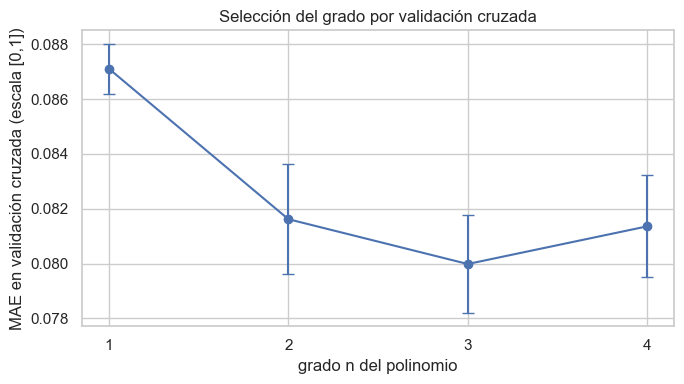

,grado_n,MAE_cv,desv_std,tiempo_ajuste_s
0,1,0.087106,0.000913,0.269962
1,2,0.081617,0.002015,1.423370
2,3,0.079982,0.001781,5.941713
3,4,0.081356,0.001859,27.111590


In [24]:
resultados_grado = (
    pd.DataFrame(busqueda_grado.cv_results_)[
        ["param_expansion__poly__degree", "mean_test_score", "std_test_score", "mean_fit_time"]
    ]
    .rename(columns={
        "param_expansion__poly__degree": "grado_n",
        "mean_test_score": "MAE_cv",
        "std_test_score": "desv_std",
        "mean_fit_time": "tiempo_ajuste_s",
    })
    .assign(MAE_cv=lambda d: -d["MAE_cv"])
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(resultados_grado["grado_n"], resultados_grado["MAE_cv"],
            yerr=resultados_grado["desv_std"], marker="o", capsize=4)
ax.set_xticks(resultados_grado["grado_n"])
ax.set_xlabel("grado n del polinomio")
ax.set_ylabel("MAE en validación cruzada (escala [0,1])")
ax.set_title("Selección del grado por validación cruzada")
plt.tight_layout()
plt.show()

resultados_grado

Evaluamos el mejor polinomio sobre el conjunto de prueba. Las predicciones se devuelven a euros con `a_euros`
antes de calcular las métricas. También reportamos el número de términos que terminó usando el modelo y el
`alpha` seleccionado por `RidgeCV`.

In [25]:
mejor_polinomio = busqueda_grado.best_estimator_
grado_optimo = busqueda_grado.best_params_["expansion__poly__degree"]

y_pred_poly = a_euros(mejor_polinomio.predict(X_test))

n_terminos = mejor_polinomio.named_steps["ridge"].coef_.shape[0]
alpha_optimo = mejor_polinomio.named_steps["ridge"].alpha_

print(f"Grado n = {grado_optimo} | términos = {n_terminos} | alpha = {alpha_optimo:.4g}")

metricas_poly = evaluar(f"Polinomio grado {grado_optimo} + Ridge", y_test_eur.to_numpy(), y_pred_poly)
pd.Series(metricas_poly).to_frame("valor")

Grado n = 3 | términos = 609 | alpha = 1000


,valor
modelo,Polinomio grado 3 + Ridge
MAE (€),114506.764036
RMSE (€),202540.743535
R2,0.563259
MAPE (%),40.780169
MedAPE (%),27.238329


---

## 7. Modelo B — Red neuronal artificial (capas densas + ReLU + sigmoide)

La red recibe **la misma matriz preprocesada** que el modelo polinomial (`X_train_prep`), sin ninguna
característica adicional. La diferencia está en cómo genera la no linealidad:

- **Capas densas con ReLU**: cada capa aprende una combinación lineal seguida de `max(0, z)`. Apilar varias
  capas produce una función lineal por tramos que aproxima interacciones de cualquier orden **sin enumerarlas
  explícitamente**, que es justo lo contrario a lo que hace `PolynomialFeatures`.
- **Salida sigmoide**: `σ(z) = 1 / (1 + e^(−z)) ∈ (0, 1)`. Acota estructuralmente la predicción al rango del
  objetivo transformado; ningún precio predicho podrá ser negativo ni desbordarse, algo que el modelo lineal no
  garantiza.
- **Dropout**: apaga aleatoriamente una fracción de neuronas en cada paso de entrenamiento, el análogo a la
  regularización Ridge del Modelo A.

La arquitectura es un embudo 256 → 128 → 64 → 1, entrenada con Adam y pérdida MSE sobre la escala [0, 1].

Keras trabaja con arreglos densos de NumPy, así que convertimos la salida del pipeline —un `DataFrame`— a
`float32`, el tipo con el que opera el backend.

In [26]:
X_train_ann = X_train_prep.to_numpy(dtype="float32")
X_test_ann = X_test_prep.to_numpy(dtype="float32")

y_train_ann = y_train.astype("float32")
y_test_ann = y_test.astype("float32")

n_features = X_train_ann.shape[1]
print("Entradas de la red:", n_features)

Entradas de la red: 63


Construcción de la red. Nótese que **solo la última capa** usa sigmoide; las intermedias usan ReLU. Si la salida
fuera lineal habría que quitar la restricción del objetivo a [0, 1]; al usar sigmoide, el escalamiento del
objetivo definido en la sección 3 no es opcional sino un requisito del diseño.

In [27]:
def construir_ann(n_entradas, tasa_dropout=0.2, tasa_aprendizaje=1e-3):
    modelo = keras.Sequential(
        [
            keras.Input(shape=(n_entradas,), name="entrada"),
            layers.Dense(256, activation="relu", name="densa_1"),
            layers.Dropout(tasa_dropout, name="dropout_1"),
            layers.Dense(128, activation="relu", name="densa_2"),
            layers.Dropout(tasa_dropout, name="dropout_2"),
            layers.Dense(64, activation="relu", name="densa_3"),
            layers.Dense(1, activation="sigmoid", name="salida"),
        ],
        name="ann_precio_inmuebles",
    )
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=tasa_aprendizaje),
        loss="mse",
        metrics=["mae"],
    )
    return modelo


ann = construir_ann(n_features)
ann.summary()

Model: "ann_precio_inmuebles"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densa_1 (Dense)                 │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,601 (225.00 KB)

 Trainable params: 57,601 (225.00 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento. `EarlyStopping` restaura los pesos de la mejor época y evita fijar de antemano el número de
épocas; `ReduceLROnPlateau` recorta la tasa de aprendizaje cuando la validación se estanca. El 15 % de
validación sale del entrenamiento: el conjunto de prueba permanece intacto.

In [28]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5, verbose=1
    ),
]

historia = ann.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.15,
    epochs=200,
    batch_size=256,
    callbacks=callbacks,
    verbose=2,
)

print("Épocas ejecutadas:", len(historia.history["loss"]))

Epoch 1/200
100/100 - 1s - 8ms/step - loss: 0.0198 - mae: 0.1091 - val_loss: 0.0145 - val_mae: 0.0926 - learning_rate: 0.0010
Epoch 2/200
100/100 - 0s - 1ms/step - loss: 0.0147 - mae: 0.0934 - val_loss: 0.0127 - val_mae: 0.0856 - learning_rate: 0.0010
Epoch 3/200
100/100 - 0s - 1ms/step - loss: 0.0131 - mae: 0.0874 - val_loss: 0.0115 - val_mae: 0.0808 - learning_rate: 0.0010
Epoch 4/200
100/100 - 0s - 1ms/step - loss: 0.0120 - mae: 0.0832 - val_loss: 0.0110 - val_mae: 0.0791 - learning_rate: 0.0010
Epoch 5/200
100/100 - 0s - 1ms/step - loss: 0.0113 - mae: 0.0808 - val_loss: 0.0106 - val_mae: 0.0775 - learning_rate: 0.0010
Epoch 6/200
100/100 - 0s - 1ms/step - loss: 0.0109 - mae: 0.0791 - val_loss: 0.0102 - val_mae: 0.0757 - learning_rate: 0.0010
Epoch 7/200
100/100 - 0s - 1ms/step - loss: 0.0104 - mae: 0.0768 - val_loss: 0.0100 - val_mae: 0.0745 - learning_rate: 0.0010
Epoch 8/200
100/100 - 0s - 1ms/step - loss: 0.0101 - mae: 0.0757 - val_loss: 0.0098 - val_mae: 0.0739 - learning_rate:

Curvas de aprendizaje. Que las curvas de entrenamiento y validación permanezcan juntas indica que el *dropout*
está conteniendo el sobreajuste; una separación creciente señalaría lo contrario.

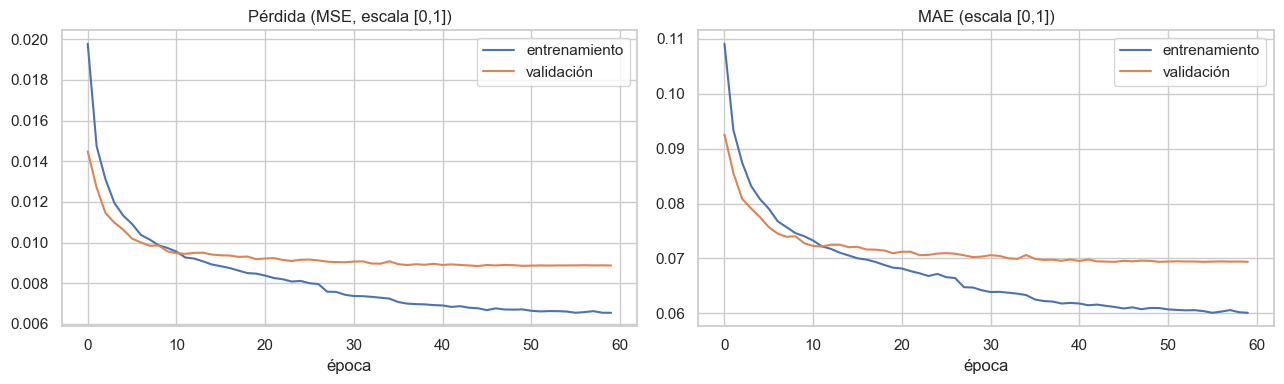

In [29]:
hist = pd.DataFrame(historia.history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist["loss"], label="entrenamiento")
axes[0].plot(hist["val_loss"], label="validación")
axes[0].set_title("Pérdida (MSE, escala [0,1])")
axes[0].set_xlabel("época")
axes[0].legend()

axes[1].plot(hist["mae"], label="entrenamiento")
axes[1].plot(hist["val_mae"], label="validación")
axes[1].set_title("MAE (escala [0,1])")
axes[1].set_xlabel("época")
axes[1].legend()

plt.tight_layout()
plt.show()

Predicción sobre el conjunto de prueba y evaluación en euros, con exactamente la misma función `evaluar` que se
usó para el polinomio.

In [30]:
y_pred_ann = a_euros(ann.predict(X_test_ann, verbose=0).ravel())

metricas_ann = evaluar("ANN (densa, ReLU, salida sigmoide)", y_test_eur.to_numpy(), y_pred_ann)
pd.Series(metricas_ann).to_frame("valor")

,valor
modelo,"ANN (densa, ReLU, salida sigmoide)"
MAE (€),95875.415494
RMSE (€),170898.87384
R2,0.689059
MAPE (%),32.303634
MedAPE (%),22.292314


---

## 8. Comparación de los modelos

Ambos modelos vieron las mismas características, el mismo objetivo transformado y la misma partición, así que
la diferencia de métricas es atribuible exclusivamente a la familia de modelos.

Tabla comparativa. El MAE y el MedAPE son los criterios más informativos para un mercado con precios tan
dispersos: el RMSE queda dominado por unos pocos inmuebles de varios millones de euros.

In [31]:
comparacion = pd.DataFrame([metricas_poly, metricas_ann]).set_index("modelo")
comparacion.round(4)

,MAE (€),RMSE (€),R2,MAPE (%),MedAPE (%)
modelo,,,,,
Polinomio grado 3 + Ridge,114506.7640,202540.7435,0.5633,40.7802,27.2383
"ANN (densa, ReLU, salida sigmoide)",95875.4155,170898.8738,0.6891,32.3036,22.2923


Predicción contra valor real en escala logarítmica. La diagonal es la predicción perfecta; la dispersión
vertical alrededor de ella muestra dónde falla cada modelo y si existe sesgo sistemático (sobreestimar los
inmuebles baratos y subestimar los caros es el patrón típico de la regresión a la media).

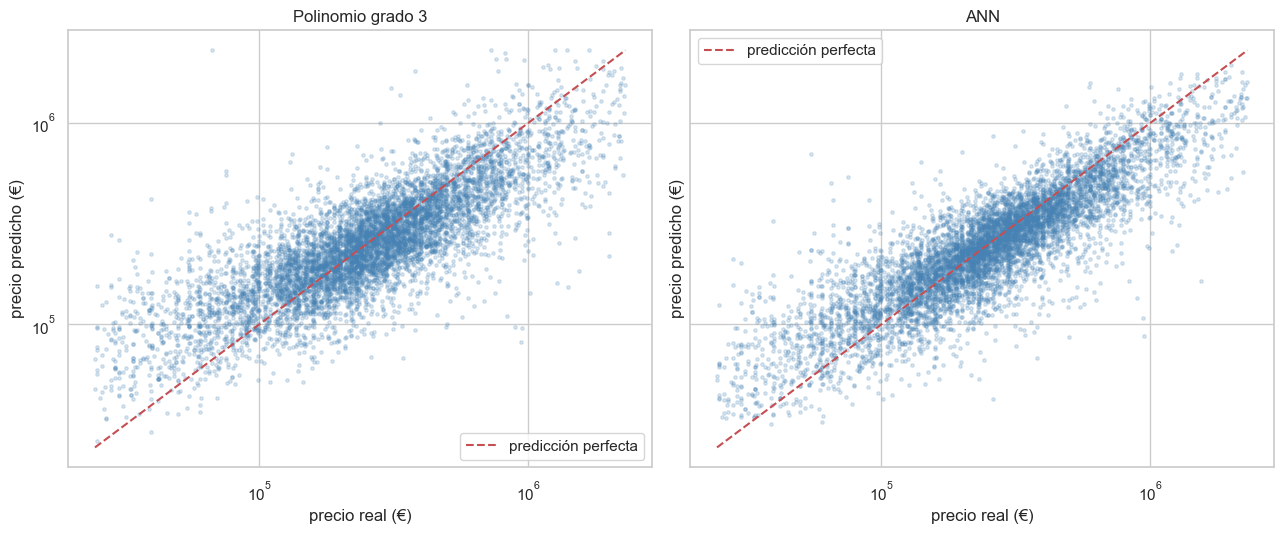

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)

for ax, (nombre, y_pred) in zip(
    axes,
    [(f"Polinomio grado {grado_optimo}", y_pred_poly), ("ANN", y_pred_ann)],
):
    ax.scatter(y_test_eur, y_pred, s=6, alpha=0.2, color="steelblue")
    limites = [y_test_eur.min(), y_test_eur.max()]
    ax.plot(limites, limites, "r--", linewidth=1.5, label="predicción perfecta")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("precio real (€)")
    ax.set_ylabel("precio predicho (€)")
    ax.set_title(nombre)
    ax.legend()

plt.tight_layout()
plt.show()

Distribución de los residuales en euros. Una distribución centrada en cero indica ausencia de sesgo; las colas
revelan el peso de los errores extremos que castiga el RMSE.

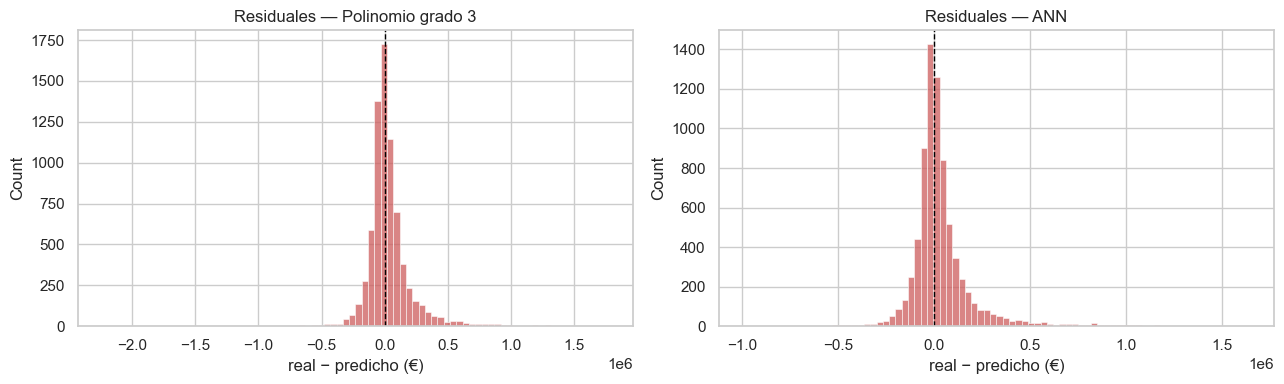

,Polinomio grado 3,ANN
count,7474.0,7474.0
mean,33707.0,36952.0
std,199730.0,166867.0
min,-2232100.0,-988138.0
25%,-53339.0,-38369.0
50%,1180.0,5759.0
75%,78847.0,68849.0
max,1770384.0,1640509.0


In [33]:
residuales = pd.DataFrame({
    f"Polinomio grado {grado_optimo}": y_test_eur.to_numpy() - y_pred_poly,
    "ANN": y_test_eur.to_numpy() - y_pred_ann,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, columna in zip(axes, residuales.columns):
    sns.histplot(residuales[columna], bins=80, ax=ax, color="indianred")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Residuales — {columna}")
    ax.set_xlabel("real − predicho (€)")

plt.tight_layout()
plt.show()

residuales.describe().round(0)

MAE por decil de precio real. Es la vista más útil para decidir cuál modelo usar en producción: revela si la
ventaja global de un modelo proviene del grueso del mercado o solo del segmento de lujo.

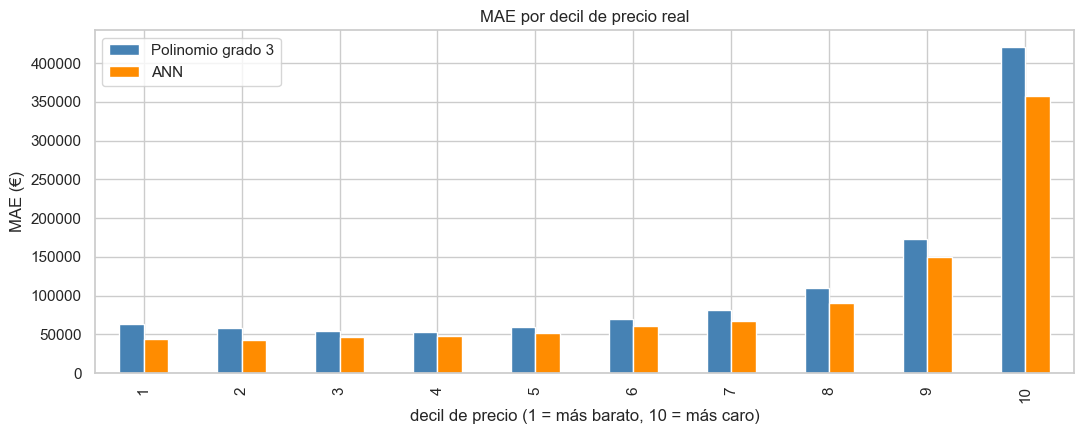

,poly,ann
decil,,
1,63025.0,43723.0
2,58359.0,42962.0
3,54976.0,47048.0
4,53365.0,47897.0
5,60040.0,51429.0
6,69360.0,60555.0
7,81555.0,66945.0
8,110523.0,91089.0
9,172941.0,150285.0


In [34]:
analisis = pd.DataFrame({
    "precio_real": y_test_eur.to_numpy(),
    "poly": np.abs(y_test_eur.to_numpy() - y_pred_poly),
    "ann": np.abs(y_test_eur.to_numpy() - y_pred_ann),
})
analisis["decil"] = pd.qcut(analisis["precio_real"], 10, labels=False) + 1

mae_por_decil = analisis.groupby("decil")[["poly", "ann"]].mean()

ax = mae_por_decil.plot(kind="bar", figsize=(11, 4.5), color=["steelblue", "darkorange"])
ax.set_title("MAE por decil de precio real")
ax.set_xlabel("decil de precio (1 = más barato, 10 = más caro)")
ax.set_ylabel("MAE (€)")
ax.legend([f"Polinomio grado {grado_optimo}", "ANN"])
plt.tight_layout()
plt.show()

mae_por_decil.round(0)

Resumen final: ganador por métrica y magnitud de la diferencia relativa.

In [35]:
resumen = comparacion.T
resumen["ganador"] = np.where(
    resumen.index.isin(["R2"]),
    np.where(resumen.iloc[:, 0] > resumen.iloc[:, 1], resumen.columns[0], resumen.columns[1]),
    np.where(resumen.iloc[:, 0] < resumen.iloc[:, 1], resumen.columns[0], resumen.columns[1]),
)
resumen["dif_relativa_%"] = (
    (resumen.iloc[:, 1] - resumen.iloc[:, 0]) / resumen.iloc[:, 0].abs() * 100
).round(2)

resumen.round(4)

modelo,Polinomio grado 3 + Ridge,"ANN (densa, ReLU, salida sigmoide)",ganador,dif_relativa_%
MAE (€),114506.7640,95875.4155,"ANN (densa, ReLU, salida sigmoide)",-16.27
RMSE (€),202540.7435,170898.8738,"ANN (densa, ReLU, salida sigmoide)",-15.62
R2,0.5633,0.6891,"ANN (densa, ReLU, salida sigmoide)",22.33
MAPE (%),40.7802,32.3036,"ANN (densa, ReLU, salida sigmoide)",-20.79
MedAPE (%),27.2383,22.2923,"ANN (densa, ReLU, salida sigmoide)",-18.16


---

## 9. Conclusiones

**Sobre el diseño experimental.** Los dos modelos comparten el pipeline completo de ingeniería de
características —winsorización, características derivadas, imputación con indicadores de ausencia,
codificación ordinal del DPE, *one-hot* con agrupación de categorías raras y codificación por objetivo de
`city`/`postal_code`— y el mismo objetivo `MinMax(log1p(price))`. La comparación aísla, por tanto, la
contribución de la familia de modelos.

**Cómo generan no linealidad.** El polinomio la enumera explícitamente: cada término es un producto concreto de
variables y su coeficiente es directamente interpretable, lo que responde al interés en interpretabilidad del
organizador; el costo es que el número de términos crece de forma combinatoria y obliga a restringir la
expansión a un núcleo numérico y a regularizar con Ridge. La red la aprende de forma implícita mediante
composiciones de ReLU: no requiere enumerar interacciones y escala mejor a muchas variables, pero sus pesos no
admiten una lectura directa.

**El papel de la salida sigmoide.** Acota la predicción al rango del objetivo transformado, lo que impide
precios negativos o desbordados —una garantía estructural que la regresión lineal no ofrece—. Su contrapartida
es la saturación: en los extremos del rango los gradientes se desvanecen, lo que dificulta ajustar los inmuebles
más baratos y más caros. El gráfico de MAE por decil permite ver ese efecto.